In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD


In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_relu_adam = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])





In [ ]:
model_relu_adam.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_relu_adam = model_relu_adam.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

test_loss, test_acc = model_relu_adam.evaluate(x_test, y_test, verbose=0)
print("Model A (ReLU + Adam) Accuracy:", test_acc)

Model A (ReLU + Adam) Accuracy: 0.9740999937057495


In [ ]:
model_sigmoid_adam = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(10, activation='softmax')
])




In [ ]:
model_sigmoid_adam.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:

history_sigmoid_adam = model_sigmoid_adam.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

test_loss, test_acc = model_sigmoid_adam.evaluate(x_test, y_test, verbose=0)
print("Model B (Sigmoid + Adam) Accuracy:", test_acc)

Model B (Sigmoid + Adam) Accuracy: 0.9706000089645386


In [ ]:
model_relu_sgd = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])




In [ ]:
model_relu_sgd.compile(
    optimizer=SGD(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [ ]:
history_relu_sgd = model_relu_sgd.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

test_loss, test_acc = model_relu_sgd.evaluate(x_test, y_test, verbose=0)
print("Model C (ReLU + SGD) Accuracy:", test_acc)

Model C (ReLU + SGD) Accuracy: 0.945900022983551


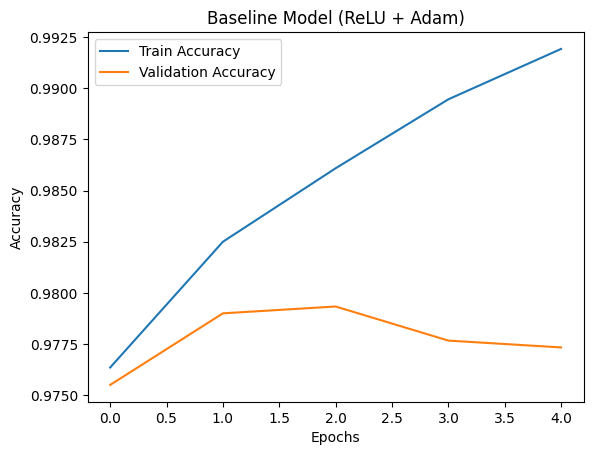

In [ ]:
plt.plot(history_relu_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_relu_adam.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Baseline Model (ReLU + Adam)")
plt.legend()
plt.show()



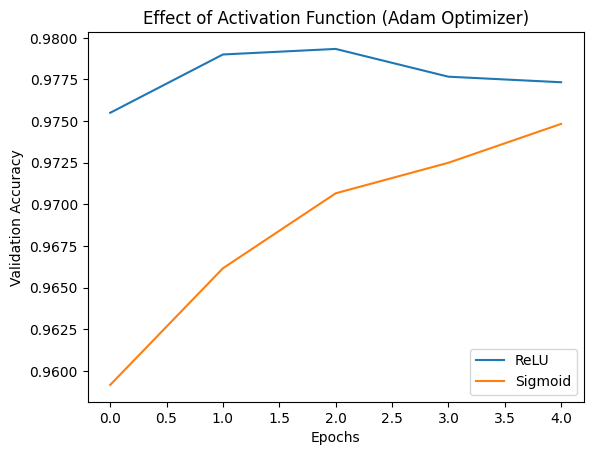

In [ ]:
plt.plot(history_relu_adam.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid_adam.history['val_accuracy'], label='Sigmoid')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Activation Function (Adam Optimizer)")
plt.legend()
plt.show()


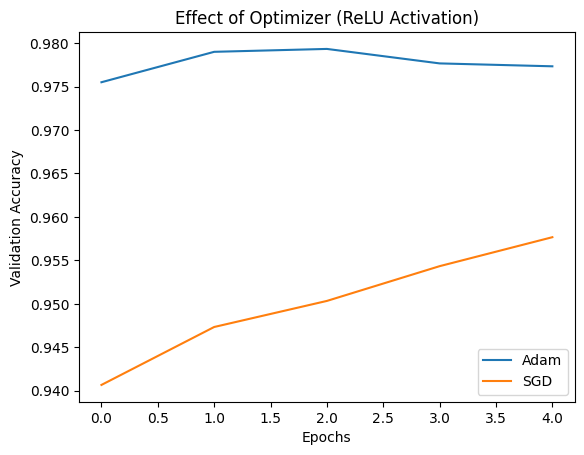

In [ ]:
plt.plot(history_relu_adam.history['val_accuracy'], label='Adam')
plt.plot(history_relu_sgd.history['val_accuracy'], label='SGD')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Optimizer (ReLU Activation)")
plt.legend()
plt.show()
